# Toy Example

First be sure the notebook is running with GPU.

Runtime -> Change Runtime Type -> GPU

In [130]:
# Colab only
# download and install Pytorch
!pip install torch torchvision

In [131]:
# import the packages
import numpy as np
from PIL import Image
from IPython.display import clear_output
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torchvision import transforms
import glob
import os
from tqdm import tqdm
# import PyTorch (Deep Learning lib)
import torch
import torch.nn as nn
import torch.nn.functional as F

import math

In [132]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [133]:
# Example of data loading from google drive:
# load an image, convert it as an array of float, and divide to have [0,1] values
# path to the image on the drive
image_filename = "/content/drive/MyDrive/Test/Misc.0001.ppm"

im = np.array(Image.open(image_filename), dtype=float)/255

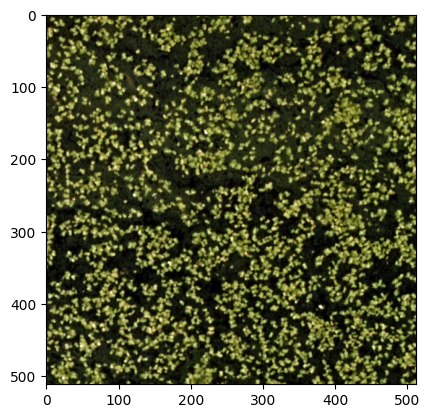

In [134]:
# display the original images
plt.figure()
plt.imshow(im)
plt.show()

## Neural network creation

The neural network is a Python class, it must inherit from the ```torch.nn.Module``` class of Pytorch.

It is composed of two main methods:
* ```__init__```, the contructor which define the layers to be used. The layers contain the paramters to be optimized
* ```forward```,  the method that define the links between the layers

As an example, we create a network based on UNet, a semantic segmeentation network.
This network has an encoder / decoder strcuture with skip connection.

To do Super Resolution, we simply use add a last block with one dimension augmentation (```upconv0```).

In [135]:
# create the neural network with Pytorch
class Mynet(nn.Module):
  """Example of network."""

  def __init__(self, in_channels, out_channels):
    """Init Unet fields."""
    super(Mynet, self).__init__()

    self.in_channels = in_channels

    self.conv = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
    self.bn = nn.BatchNorm2d(64)

    self.conv2 = nn.Conv2d(64, out_channels, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(3)


  def forward(self, x):
    """Forward method."""

    x = F.relu(self.bn(self.conv(x)))
    x = F.relu(self.bn2(self.conv2(x)))

    return x

In [136]:
# actual network creation
net = Mynet(3,3)
net.cuda() # go GPU



Mynet(
  (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

## Dataset and dataloader

Functions that create a dataset and will randomly extract batches of images from it and apply required transformation (normalisation, crop etc...)

In [137]:
class MyImageDataset(Dataset):
    """Sharp image dataset and transform"""
   # creates a dataset from an image folder
    def __init__(self,root_dir, motif,transform=None):

        self.transform = transform
        self.list_im=sorted(glob.glob(os.path.join(root_dir,motif)))


    def __len__(self):
        return len(self.list_im)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()


        input_path = self.list_im[idx]

        ## open the image

        sample=Image.open(input_path)



        if self.transform:

            sample = self.transform(sample)

        return sample

In [138]:
#batchsize
bs=4
# folder containing the images
folder = "/content/drive/MyDrive/Test/"
PatchSize = 64

# define transformation applied to the data
my_transform = transforms.Compose([
transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),transforms.RandomCrop(PatchSize),transforms.ToTensor()
     ])


dataset=MyImageDataset(folder,"*.ppm",transform=my_transform)

# sample of the dataset
batch_test = dataset[0]
# length of the dataset
print(len(dataset))
# batch size
print(batch_test.shape)


dataset_train, dataset_test = torch.utils.data.random_split(dataset, [0.8, 0.2])


dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=bs, pin_memory=True, shuffle=True, num_workers=2)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bs, pin_memory=True, shuffle=True, num_workers=2)


9
torch.Size([3, 64, 64])


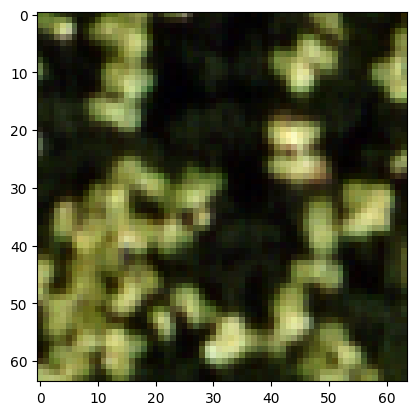

In [139]:
plt.figure()
plt.imshow(batch_test.numpy().transpose(1,2,0))

## Optimization

There are two steps.
First we create the optimizer and then, we loop over the dataset N_epoch times and optimize the network weights.

In [140]:
# create the optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
# number of epoch
N_EPOCH = 500

In [ ]:
# Epoch loops (the number of times we see the training dataset)
for epoch in tqdm(range(N_EPOCH)):

    for u, batch in enumerate(dataloader_train):  # iterate over the dataset (

    # forward pass, compute the output of the network

      batch= batch.cuda()

    # reinitialize the gradients
      optimizer.zero_grad()

     # apply any perturbation to the patch (noise etc)

      outputs = net(batch)

      # compute the error (here mean square error)
      loss = F.mse_loss(outputs, batch)

      # compute the gradients
      loss.backward()

      # update the weights
      optimizer.step()

      print(loss.item())




  0%|          | 1/500 [00:00<01:02,  8.02it/s]

0.387307733297348
0.3141343593597412


  0%|          | 2/500 [00:00<01:02,  7.98it/s]

0.2376500815153122
0.32473522424697876


  1%|          | 3/500 [00:00<01:02,  7.98it/s]

...

0.024867311120033264
0.007046977058053017


 52%|█████▏    | 258/500 [00:41<00:32,  7.45it/s]

0.01671621948480606
0.01219415944069624


 52%|█████▏    | 259/500 [00:41<00:32,  7.45it/s]

0.01899014040827751
0.015602308325469494
